In [35]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import joblib


In [17]:
# directories

data_dir = "/Users/derekwu/Desktop/Data/01_silver"
mod_dir = "/Users/derekwu/Desktop/Data/20_models"

In [18]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# MAPE (Mean Absolute Percentage Error)
def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# SMAPE (Symmetric Mean Absolute Percentage Error)
def calculate_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

# RMSE (Root Mean Squared Error)
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_error_metrics(y_true, y_pred):
    """
    Calculate a vector of error metrics.
    Args:
        y_true: Actual values.
        y_pred: Predicted values.
    Returns:
        A dictionary of error metrics.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = calculate_rmse(y_true, y_pred)
    mape = calculate_mape(y_true, y_pred)
    smape = calculate_smape(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        'mse': mse,
        'rmse': rmse,
        'mape': mape,
        'smape': smape,
        'r2': r2
    }

## **Prediction metrics**

In [19]:
# Load the saved model
best_model_name = "XGBoost"
loaded_model = joblib.load(f'{mod_dir}/best_model_{best_model_name}.pkl')
print(f"Loaded {best_model_name} successfully.")

Loaded XGBoost successfully.


In [103]:
# Prepare new data for prediction
# data = pd.read_csv(f"{data_dir}/test_chs_waittimes.csv")
data = pd.read_csv(f"{data_dir}/daytest_chs_waittimes.csv")

# Encode 'id' and 'clinic_type'
label_encoder_id = LabelEncoder()
label_encoder_clinic_type = LabelEncoder()

data['id_encoded'] = label_encoder_id.fit_transform(data['id'])
data['clinic_type_encoded'] = label_encoder_clinic_type.fit_transform(data['clinic_type'])

# Drop original categorical columns to avoid redundancy
data = data[data['id'] == "CBRHOSED"]
# data = data[data['id'] == "NORHOSED"]
data = data.drop(columns=['id', 'clinic_type'])

# Map days of the week to numeric values
day_mapping = {
    'Monday': 0, 'Tuesday': 1, 'Wednesday': 2,
    'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6
}

data['day_of_week_encoded'] = data['day_of_week'].map(day_mapping)

data = data.dropna()

# Split data into training and testing sets
# WIC == 1, ED == 0

X = data[data['clinic_type_encoded'] == 0][['queue', 'treat_time', 'queue_diff', 'hour_minute_numeric', 'hour_minute_numeric_diff', 'id_encoded', 'clinic_type_encoded', 'day_of_week_encoded',
                                            'lagged_queue', 'lagged_treat_time', 'lagged_queue_diff', 'lagged_hour_minute_numeric', 'lagged_hour_minute_numeric_diff']]
y = data[data['clinic_type_encoded'] == 0][['wait_time']]

# X = data[data['clinic_type_encoded'] == 1][['queue', 'treat_time', 'queue_diff', 'hour_minute_numeric', 'hour_minute_numeric_diff', 'id_encoded', 'clinic_type_encoded', 'day_of_week_encoded',
#                                            'lagged_queue', 'lagged_treat_time', 'lagged_queue_diff', 'lagged_hour_minute_numeric', 'lagged_hour_minute_numeric_diff']]
# y = data[data['clinic_type_encoded'] == 1][['wait_time']]

# Align indices
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

In [104]:
# Make predictions with the loaded model
y_pred = loaded_model.predict(X)
y_true = y['wait_time'].to_numpy()

In [105]:
# Calculate error metrics
error_metrics = calculate_error_metrics(y_true, y_pred)

# Print metrics
for metric, value in error_metrics.items():
    print(f"{metric}: {value:.4f}")

mse: 0.0641
rmse: 0.2531
mape: 9.1715
smape: 9.0476
r2: 0.8698


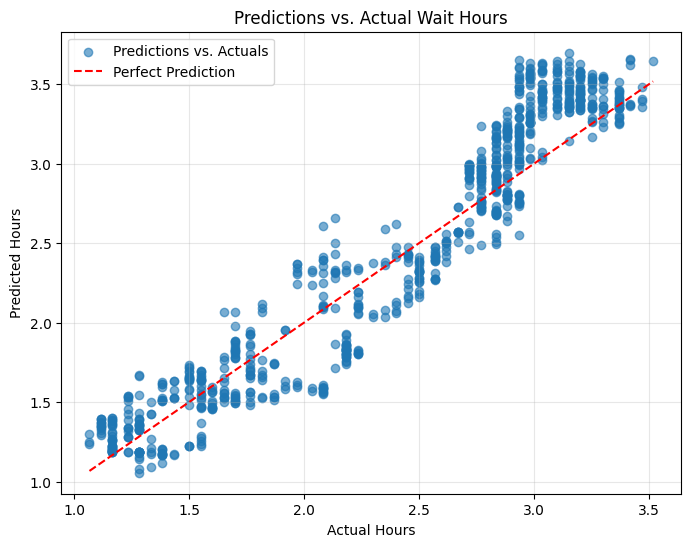

In [110]:
# Ensure y_true and y_pred are arrays
y_true_array = y_true.squeeze()  # Convert to NumPy array if needed
y_pred_array = np.array(y_pred)  # Ensure y_pred is also a NumPy array

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_true_array, y_pred_array, alpha=0.6, label="Predictions vs. Actuals")
plt.plot([min(y_true_array), max(y_true_array)], [min(y_true_array), max(y_true_array)], 'r--', label="Perfect Prediction")
plt.xlabel("Actual Hours")
plt.ylabel("Predicted Hours")
plt.title("Predictions vs. Actual Wait Hours")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

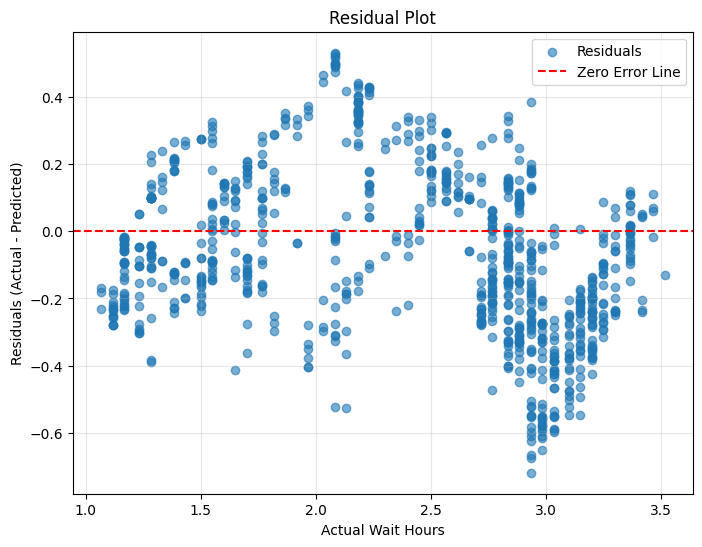

In [111]:
# Residuals
residuals = y_true_array - y_pred_array

# Residual plot
plt.figure(figsize=(8, 6))
plt.scatter(y_true_array, residuals, alpha=0.6, label="Residuals")
plt.axhline(0, color='red', linestyle='--', label="Zero Error Line")
plt.xlabel("Actual Wait Hours")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

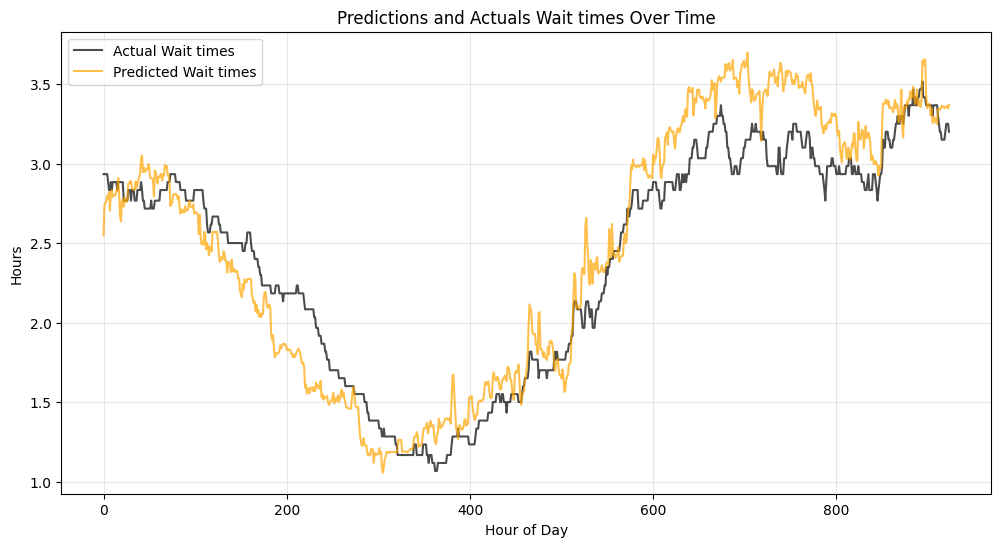

In [109]:
# Line plot
plt.figure(figsize=(12, 6))
plt.plot(y_true_array, label="Actual Wait times", color="black", alpha=0.7)
plt.plot(y_pred_array, label="Predicted Wait times", color="orange", alpha=0.7)
plt.xlabel("Hour of Day")
plt.ylabel("Hours")
plt.title("Predictions and Actuals Wait times Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()